📁 Output images will be saved in: outputs/
✅ Dataset loaded successfully. Shape: (2000, 21)
Training samples: 1600, Testing samples: 400

(1) Closed-form: MSE = 2593761.44, R² = 0.9101
(2) Gradient Descent: MSE = 116583018.32, R² = -3.0428


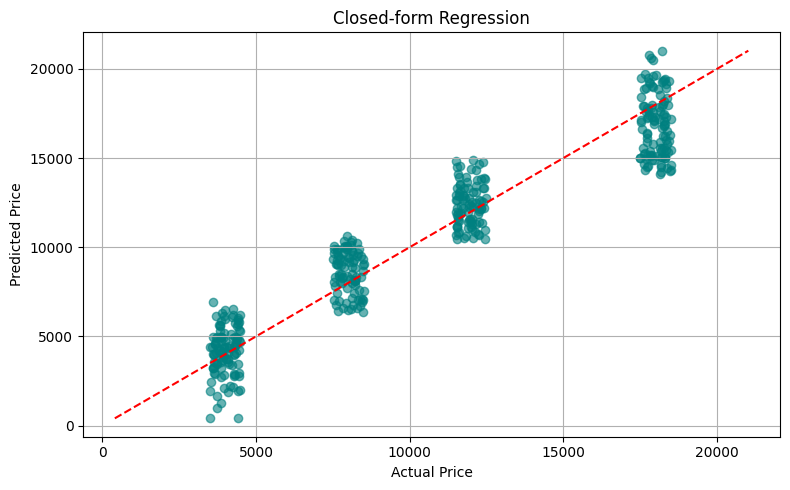

📊 Saved plot: closed_form_pred_vs_actual.png


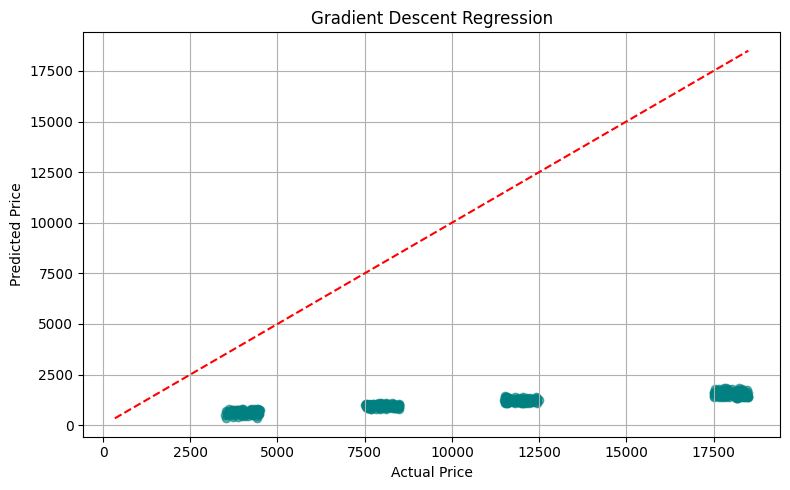

📊 Saved plot: gradient_descent_pred_vs_actual.png


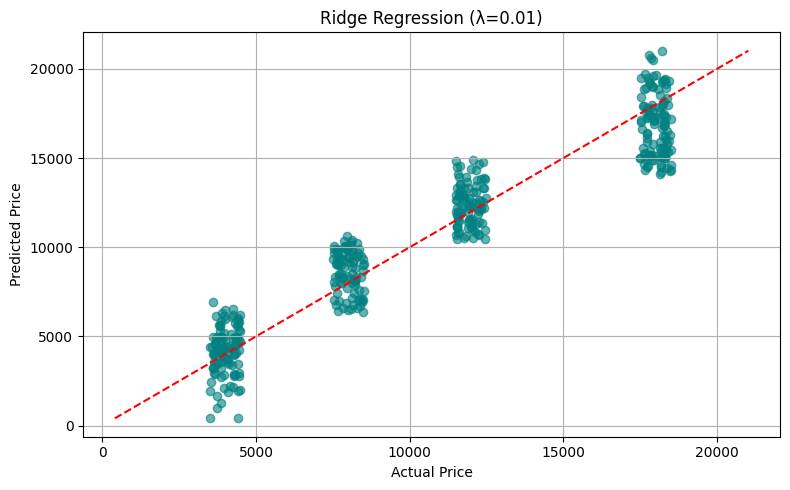

📊 Saved plot: ridge_lambda_0.01.png


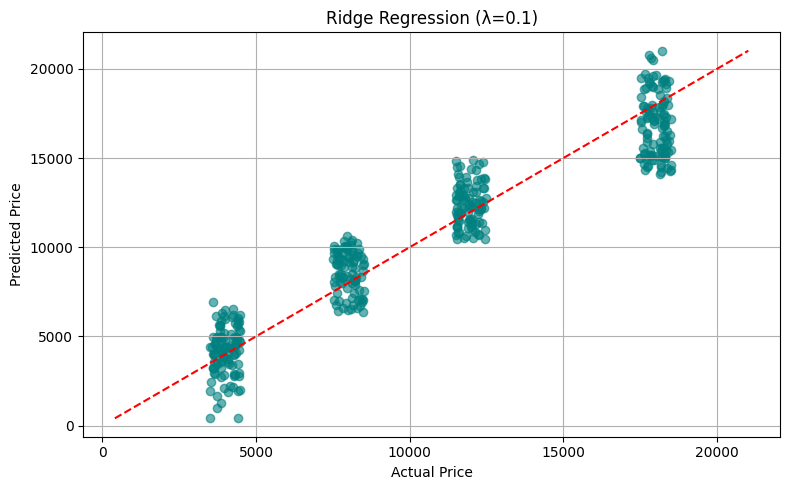

📊 Saved plot: ridge_lambda_0.1.png


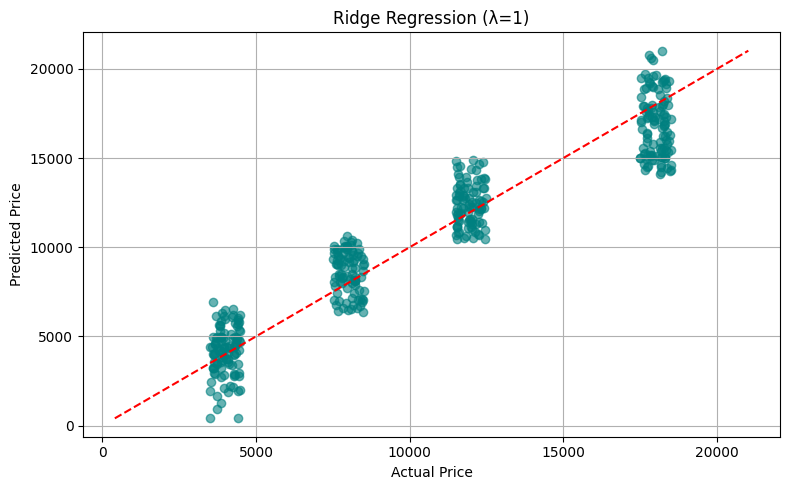

📊 Saved plot: ridge_lambda_1.png


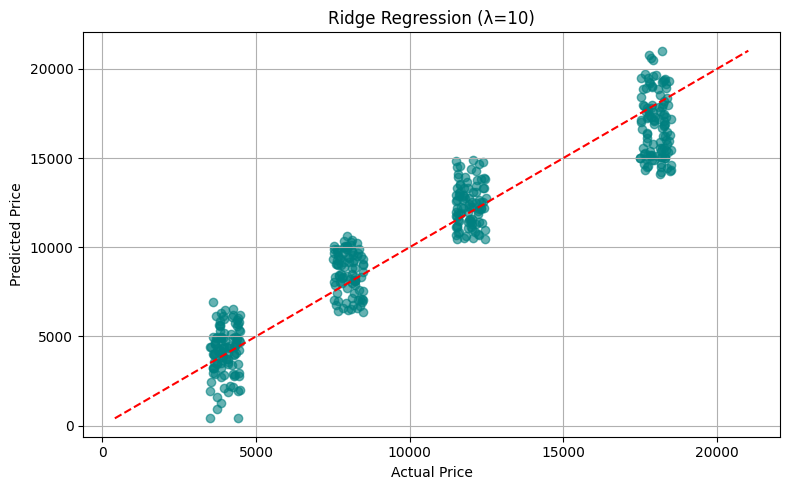

📊 Saved plot: ridge_lambda_10.png


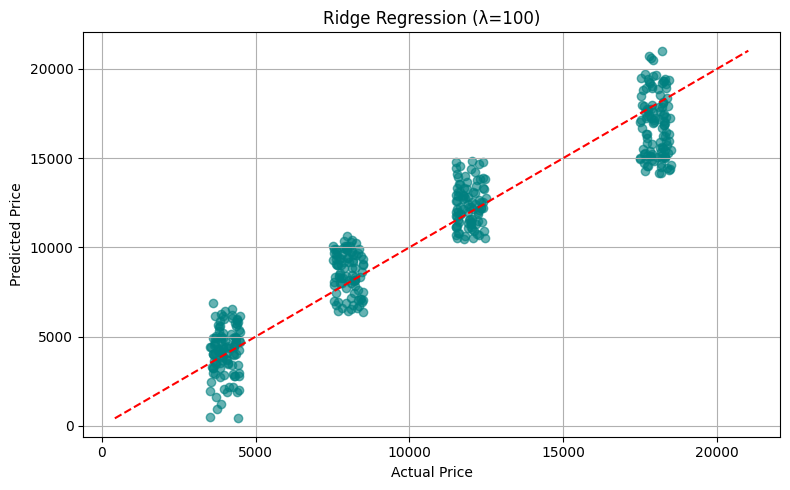

📊 Saved plot: ridge_lambda_100.png


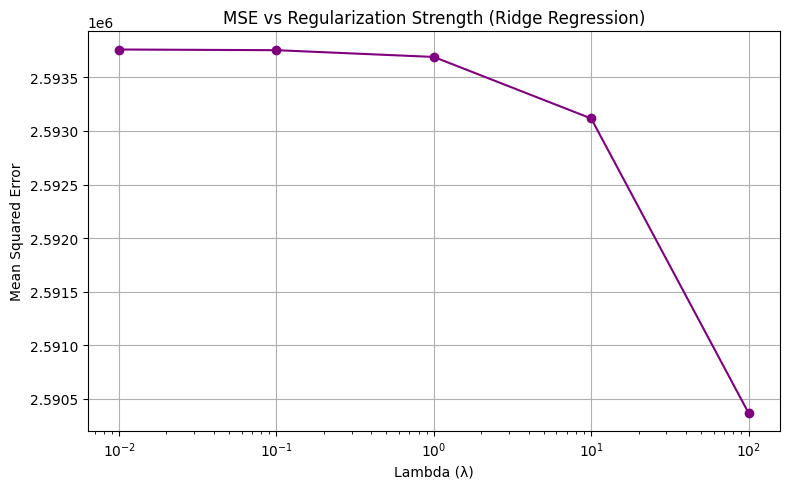

📊 Saved plot: ridge_mse_vs_lambda.png

With Standardization: MSE=2594131.49
Without Standardization: MSE=2593691.29


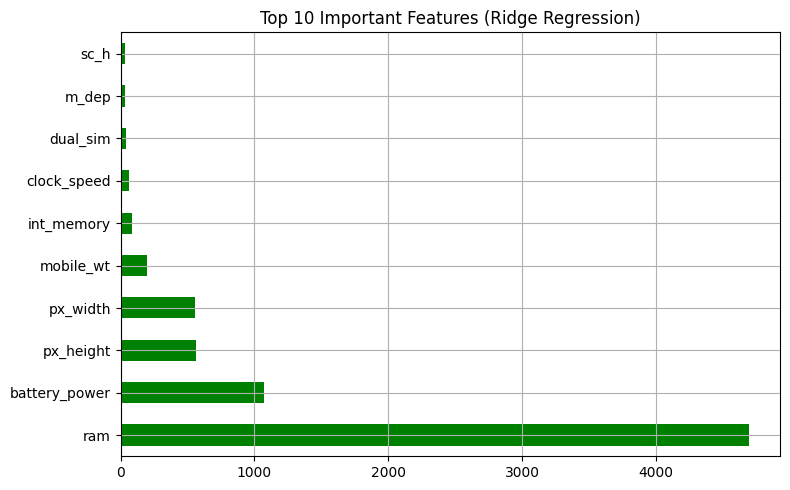

📊 Saved plot: feature_importance.png


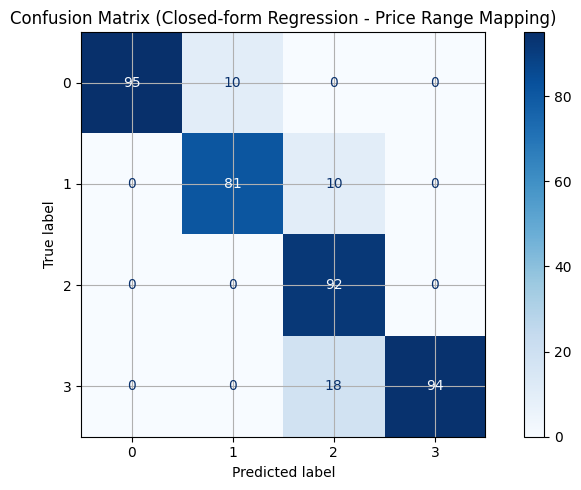

📊 Saved plot: confusion_matrix_price_ranges.png

✅ All plots saved successfully in 'outputs/' folder.


In [ ]:
# ============================================================
# ICS1502 - Introduction to Machine Learning
# Assignment 1.1 - Regression: Mobile Phone Price Prediction
# ============================================================

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

# --- Settings ---
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

# --- Create folder for output images ---
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Output images will be saved in: {output_dir}/")

# ============================================================
# STEP 1: Load Dataset (from Kaggle)
# ============================================================
# Dataset: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification
# Ensure 'train.csv' is in the same directory

data = pd.read_csv("train.csv")
print("✅ Dataset loaded successfully. Shape:", data.shape)

# Convert price_range (0–3) to approximate continuous price targets
price_map = {0: 4000, 1: 8000, 2: 12000, 3: 18000}
data["price"] = data["price_range"].map(price_map) + np.random.randint(-500, 500, len(data))

# Define features and target
X = data.drop(["price_range", "price"], axis=1)
y = data["price"]

# ============================================================
# STEP 2: Train-Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ============================================================
# STEP 3: Closed-form Linear Regression (Normal Equation)
# ============================================================
def add_intercept(X):
    """Add intercept (bias column)"""
    return np.c_[np.ones((X.shape[0], 1)), X]

X_train_b = add_intercept(X_train.values)
X_test_b = add_intercept(X_test.values)
y_train_vec = y_train.values.reshape(-1, 1)
y_test_vec = y_test.values.reshape(-1, 1)

# Normal Equation
theta_cf = np.linalg.pinv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train_vec)
y_pred_cf = X_test_b @ theta_cf

mse_cf = mean_squared_error(y_test_vec, y_pred_cf)
r2_cf = r2_score(y_test_vec, y_pred_cf)
print(f"\n(1) Closed-form: MSE = {mse_cf:.2f}, R² = {r2_cf:.4f}")

# ============================================================
# STEP 4: Gradient Descent Implementation
# ============================================================
def gradient_descent(X, y, lr=1e-12, iterations=6000, lam=0.0):
    """Batch Gradient Descent with optional L2 regularization"""
    m, n = X.shape
    X_b = add_intercept(X)
    theta = np.zeros((n + 1, 1))
    y = y.reshape(-1, 1)
    for _ in range(iterations):
        gradient = (2 / m) * X_b.T @ (X_b @ theta - y) + 2 * lam * np.r_[[[0]], theta[1:]]
        theta -= lr * gradient
    return theta

theta_gd = gradient_descent(X_train.values, y_train_vec)
y_pred_gd = add_intercept(X_test.values) @ theta_gd
mse_gd = mean_squared_error(y_test_vec, y_pred_gd)
r2_gd = r2_score(y_test_vec, y_pred_gd)
print(f"(2) Gradient Descent: MSE = {mse_gd:.2f}, R² = {r2_gd:.4f}")

# ============================================================
# STEP 5: Plot Predicted vs Actual (for both methods)
# ============================================================
def plot_pred_vs_actual(y_true, y_pred, title, filename):
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.6, color='teal')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename))
    plt.show()
    print(f"📊 Saved plot: {filename}")

plot_pred_vs_actual(y_test_vec, y_pred_cf, "Closed-form Regression", "closed_form_pred_vs_actual.png")
plot_pred_vs_actual(y_test_vec, y_pred_gd, "Gradient Descent Regression", "gradient_descent_pred_vs_actual.png")

# ============================================================
# STEP 6: Ridge Regression (L2 Regularization)
# ============================================================
def ridge_closed_form(X, y, lam):
    X_b = add_intercept(X)
    n = X_b.shape[1]
    I = np.eye(n)
    I[0, 0] = 0  # Don’t regularize intercept
    return np.linalg.pinv(X_b.T @ X_b + lam * I) @ (X_b.T @ y)

lambdas = [0.01, 0.1, 1, 10, 100]
mse_list = []

for lam in lambdas:
    theta_r = ridge_closed_form(X_train.values, y_train_vec, lam)
    y_pred_r = add_intercept(X_test.values) @ theta_r
    mse_list.append(mean_squared_error(y_test_vec, y_pred_r))
    plot_pred_vs_actual(y_test_vec, y_pred_r, f"Ridge Regression (λ={lam})", f"ridge_lambda_{lam}.png")

plt.figure()
plt.semilogx(lambdas, mse_list, marker='o', color='purple')
plt.xlabel("Lambda (λ)")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Regularization Strength (Ridge Regression)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "ridge_mse_vs_lambda.png"))
plt.show()
print("📊 Saved plot: ridge_mse_vs_lambda.png")

# ============================================================
# STEP 7: With & Without Standardization + Feature Importance
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

theta_scaled = ridge_closed_form(X_train_scaled, y_train_vec, lam=1.0)
theta_unscaled = ridge_closed_form(X_train.values, y_train_vec, lam=1.0)

y_pred_scaled = add_intercept(X_test_scaled) @ theta_scaled
y_pred_unscaled = add_intercept(X_test.values) @ theta_unscaled

print(f"\nWith Standardization: MSE={mean_squared_error(y_test_vec, y_pred_scaled):.2f}")
print(f"Without Standardization: MSE={mean_squared_error(y_test_vec, y_pred_unscaled):.2f}")

# Feature Importance Plot
feature_importance = pd.Series(np.abs(theta_scaled[1:].flatten()), index=X.columns)
plt.figure()
feature_importance.nlargest(10).plot(kind='barh', color='green')
plt.title("Top 10 Important Features (Ridge Regression)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importance.png"))
plt.show()
print("📊 Saved plot: feature_importance.png")

# ============================================================
# STEP 8: Confusion Matrix (Predicted vs Actual Price Ranges)
# ============================================================
def map_to_price_range(price):
    """Convert continuous price into categorical price range"""
    if price < 6000:
        return 0
    elif price < 10000:
        return 1
    elif price < 15000:
        return 2
    else:
        return 3

y_true_range = [map_to_price_range(p) for p in y_test_vec.flatten()]
y_pred_range = [map_to_price_range(p) for p in y_pred_cf.flatten()]

cm = confusion_matrix(y_true_range, y_pred_range)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Closed-form Regression - Price Range Mapping)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix_price_ranges.png"))
plt.show()
print("📊 Saved plot: confusion_matrix_price_ranges.png")

# ============================================================
# END OF ASSIGNMENT 1.1
# ============================================================

print("\n✅ All plots saved successfully in 'outputs/' folder.")
